# Diabetes Prediction Using Classification Models

This notebook builds Logistic Regression, Decision Tree, and K-Nearest Neighbors models and compares them using Accuracy, Precision, Recall, F1-score, confusion matrices, and ROC-AUC.

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


## 1. Load the dataset

The following code finds `diabetes_prediction_dataset.csv` automatically on Kaggle. It also works locally when the CSV is in the notebook folder.

In [2]:
# Find the CSV file
possible_paths = [
    'diabetes_prediction_dataset.csv',
    '/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv',
    '/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv'
]

csv_path = next((path for path in possible_paths if os.path.exists(path)), None)

if csv_path is None:
    for folder, _, files in os.walk('/kaggle/input'):
        for file in files:
            if file.lower() == 'diabetes_prediction_dataset.csv':
                csv_path = os.path.join(folder, file)
                break
        if csv_path:
            break

if csv_path is None:
    raise FileNotFoundError('Add the Kaggle diabetes dataset, then run this cell again.')

df = pd.read_csv(csv_path)
print('Dataset loaded from:', csv_path)
print('Dataset shape:', df.shape)
df.head()


Dataset loaded from: diabetes_prediction_dataset.csv
Dataset shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Understand and clean the data

In [3]:
# Display column names, data types, and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
# Display numerical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [5]:
# Check missing values and duplicate rows
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())


Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3854


In [6]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# BMI and blood glucose cannot realistically be zero.
# Replace invalid zeros with missing values so the pipeline can use the median.
for column in ['bmi', 'blood_glucose_level']:
    if column in df.columns:
        df[column] = df[column].replace(0, np.nan)

print('Shape after removing duplicates:', df.shape)
print('Missing/invalid values to be handled by the model pipeline:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Shape after removing duplicates: (96146, 9)
Missing/invalid values to be handled by the model pipeline:
Series([], dtype: int64)


## 3. Quick visual checks

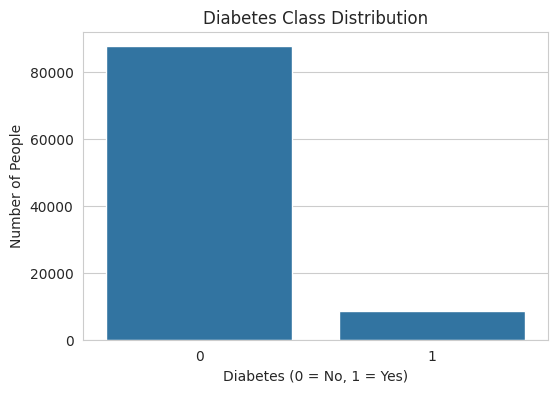

In [7]:
# Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diabetes')
plt.title('Diabetes Class Distribution')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Number of People')
plt.show()


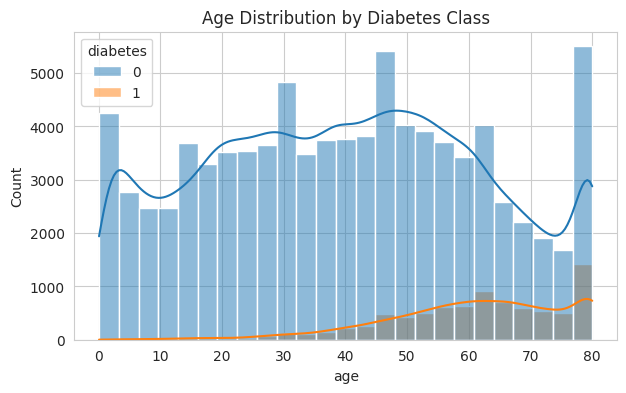

In [8]:
# Age distribution by target class
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='age', hue='diabetes', bins=25, kde=True)
plt.title('Age Distribution by Diabetes Class')
plt.show()


## 4. Separate input features and target

In [9]:
# X contains the input columns and y contains the target column
X = df.drop(columns=['diabetes'])
y = df['diabetes']

print('Input shape:', X.shape)
print('Target shape:', y.shape)


Input shape: (96146, 8)
Target shape: (96146,)


## 5. Split the data

`stratify=y` keeps the same diabetes class percentage in training and testing data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Training rows: 76916
Testing rows: 19230


## 6. Prepare numerical and categorical columns

Missing numerical values are filled with the median and scaled. Missing categorical values are filled with the most frequent value and converted to numbers using one-hot encoding. Fitting these steps only on training data prevents data leakage.

In [11]:
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(exclude=np.number).columns.tolist()

numerical_steps = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_steps = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numbers', numerical_steps, numerical_columns),
    ('categories', categorical_steps, categorical_columns)
])

print('Numerical columns:', numerical_columns)
print('Categorical columns:', categorical_columns)


Numerical columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical columns: ['gender', 'smoking_history']


## 7. Create and train three classification models

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=10,
                                            class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

trained_models = {}
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1-score': f1_score(y_test, predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,KNN,0.9603,0.9125,0.6085,0.7301,0.9156
0,Logistic Regression,0.8845,0.4251,0.8797,0.5732,0.9601
1,Decision Tree,0.8707,0.3997,0.9292,0.5590,0.9713


## 8. Classification reports

In [13]:
for name, pipeline in trained_models.items():
    predictions = pipeline.predict(X_test)
    print('\n', '=' * 55)
    print(name)
    print('=' * 55)
    print(classification_report(y_test, predictions, zero_division=0))



Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230


Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.87      0.92     17534
           1       0.40      0.93      0.56      1696

    accuracy                           0.87     19230
   macro avg       0.70      0.90      0.74     19230
weighted avg       0.94      0.87      0.89     19230


KNN
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.91      0.61      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.94      0.80      0.85     19230
weighted avg       0.96      0.96

## 9. Confusion matrices

The matrices show true negatives, false positives, false negatives, and true positives for each model.

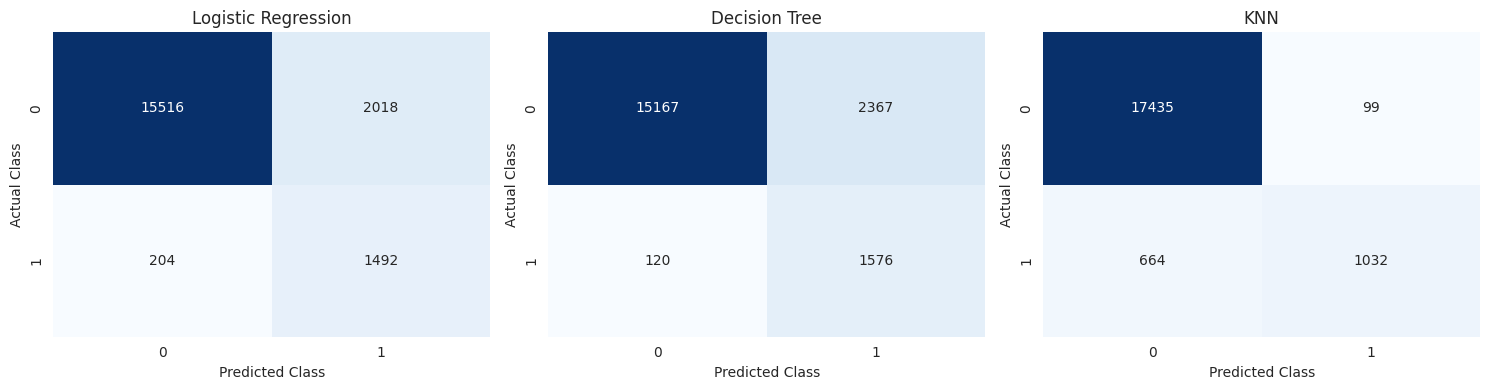

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (name, pipeline) in zip(axes, trained_models.items()):
    predictions = pipeline.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)

    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(name)
    axis.set_xlabel('Predicted Class')
    axis.set_ylabel('Actual Class')

plt.tight_layout()
plt.show()


## 10. ROC curves

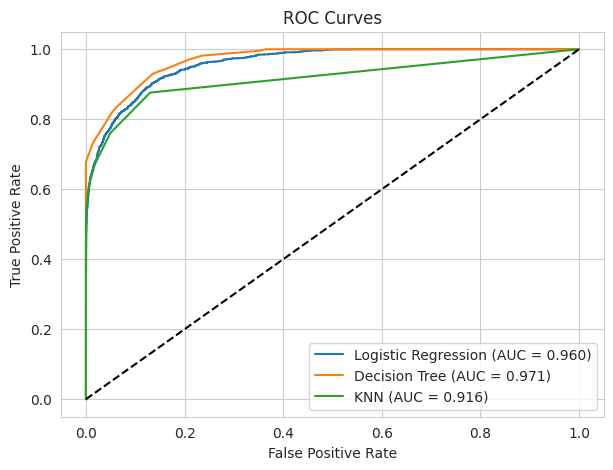

In [15]:
plt.figure(figsize=(7, 5))

for name, pipeline in trained_models.items():
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    plt.plot(false_positive_rate, true_positive_rate, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


## 11. Select the best model

Because the diabetes-positive class is much smaller than the negative class, accuracy alone can be misleading. The notebook selects the model with the highest F1-score because F1 balances precision and recall. ROC-AUC is used as supporting evidence.

In [16]:
best_row = results_df.iloc[0]
best_model_name = best_row['Model']

print('Best model:', best_model_name)
print('Accuracy:', round(best_row['Accuracy'], 4))
print('Precision:', round(best_row['Precision'], 4))
print('Recall:', round(best_row['Recall'], 4))
print('F1-score:', round(best_row['F1-score'], 4))
print('ROC-AUC:', round(best_row['ROC-AUC'], 4))

print(f'\nConclusion: {best_model_name} is selected because it has the highest '
      'F1-score on unseen test data. This provides the best balance between '
      'correctly identifying diabetes cases and limiting false alarms. '
      'Its ROC-AUC also shows how well it separates the two classes across thresholds.')


Best model: KNN
Accuracy: 0.9603
Precision: 0.9125
Recall: 0.6085
F1-score: 0.7301
ROC-AUC: 0.9156

Conclusion: KNN is selected because it has the highest F1-score on unseen test data. This provides the best balance between correctly identifying diabetes cases and limiting false alarms. Its ROC-AUC also shows how well it separates the two classes across thresholds.


## Final Summary

- Three models were trained: Logistic Regression, Decision Tree, and KNN.
- All models used the same stratified train/test split.
- Numerical and categorical preprocessing was learned only from training data.
- Accuracy, Precision, Recall, F1-score, confusion matrices, and ROC-AUC were compared.
- The model with the highest test F1-score was selected because the target classes are imbalanced.